In [1]:
!pip install langgraph

In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [3]:
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [4]:
def step_1(state:CrashState)->CrashState:
    print("Step 1 executed")
    return {"step1":"done","input":state["input"]}

def step_2(state:CrashState)->CrashState:
    print("Step 2 hanging...now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)
    return {"step2":"done"}

def step_3(state:CrashState)->CrashState:
    print("Step 3 executed")
    return {"done":True}


In [5]:
builder = StateGraph(CrashState)
builder.add_node("step_1",step_1)
builder.add_node("step_2",step_2)
builder.add_node("step_3",step_3)

builder.add_edge(START,"step_1")
builder.add_edge("step_1","step_2")
builder.add_edge("step_2","step_3")
builder.add_edge("step_1",END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

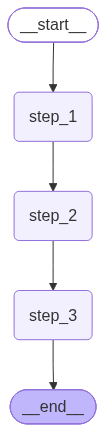

In [6]:
graph

In [7]:
try:
    print("Running Graph, please manually interrupt during step 2")
    graph.invoke({"input":"start"},config={"configurable":{"thread_id":"thread-1"}})
except KeyboardInterrupt:
    print("Kerne manually interrupted(Crash simulated).")

Running Graph, please manually interrupt during step 2
Step 1 executed
Step 2 hanging...now manually interrupt from the notebook toolbar (STOP button)
Kerne manually interrupted(Crash simulated).


In [8]:
graph.get_state({"configurable":{"thread_id":"thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc81-f802-66d3-8001-aa70787a5c3e'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-04T05:48:30.991916+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc81-f7ff-674f-8000-8c88b55968f3'}}, tasks=(PregelTask(id='6a40d749-d353-0b56-2562-c74b6f16806b', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [9]:
list(graph.get_state_history({"configurable":{"thread_id":"thread-1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc81-f802-66d3-8001-aa70787a5c3e'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-04T05:48:30.991916+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc81-f7ff-674f-8000-8c88b55968f3'}}, tasks=(PregelTask(id='6a40d749-d353-0b56-2562-c74b6f16806b', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc81-f7ff-674f-8000-8c88b55968f3'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-04T05:48:30.990708+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch

In [13]:
final_state = graph.invoke(None,config={"configurable":{"thread_id":"thread-1"}})
print("Final State : ",final_state)

Step 2 hanging...now manually interrupt from the notebook toolbar (STOP button)
Step 3 executed
Final State :  {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [14]:
graph.get_state({"configurable":{"thread_id":"thread-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc97-c85a-6269-8003-7d770f15adb0'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-04T05:58:16.552676+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc97-c855-69ee-8002-3384c6008d81'}}, tasks=(), interrupts=())

In [15]:
list(graph.get_state_history({"configurable":{"thread_id":"thread-1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc97-c85a-6269-8003-7d770f15adb0'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-08-04T05:58:16.552676+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc97-c855-69ee-8002-3384c6008d81'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc97-c855-69ee-8002-3384c6008d81'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-08-04T05:58:16.550816+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f18fc81-f802-66d3-8001-aa70787a5c3e'}}, tasks=(PregelTask(id='5478b46b-3d1f-6aaa-59ac-916c5206c65